In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch

In [7]:
W = torch.randn((27, 200))
# W = W * 0.01  # Scale down the weights
h = torch.tanh(W)
h.shape

torch.Size([27, 200])

In [8]:
h.view(-1).shape # 27 * 200 = 5400

torch.Size([5400])

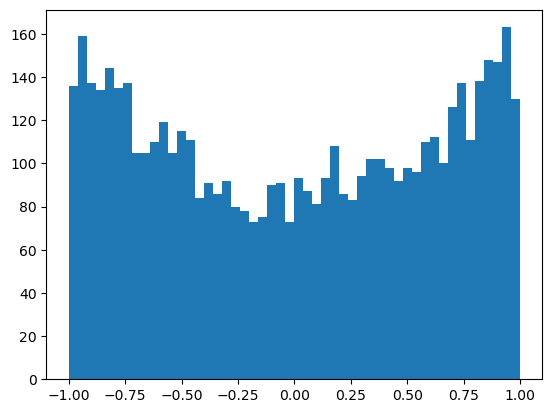

In [9]:
plt.hist(h.view(-1).tolist(), bins=50);

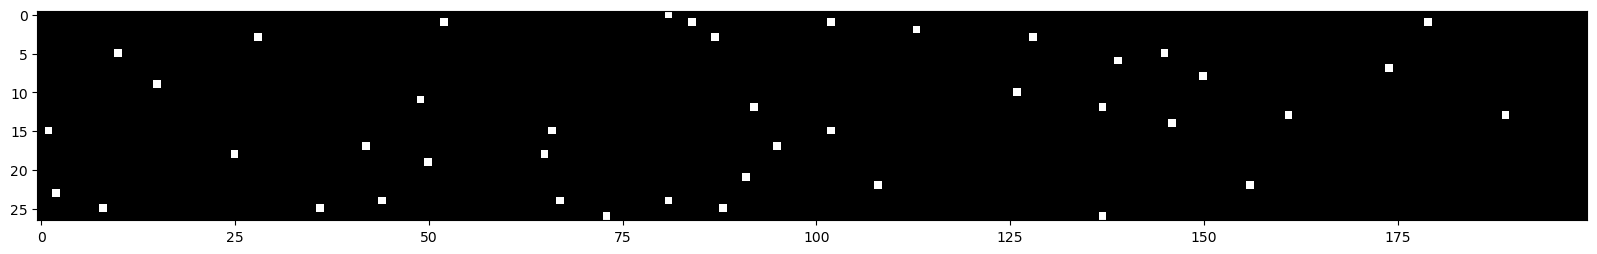

In [10]:
plt.figure(figsize=(20,20))
plt.imshow(h.abs() > 0.99, cmap='gray',interpolation='nearest');

> Let's scale the weights down to see the distribution of the activations.

```python
W = W * 0.01  # Scale down the weights
```

In [11]:
W = torch.randn((27, 200))
W = W * 0.01  # Scale down the weights
h = torch.tanh(W)
h.shape

torch.Size([27, 200])

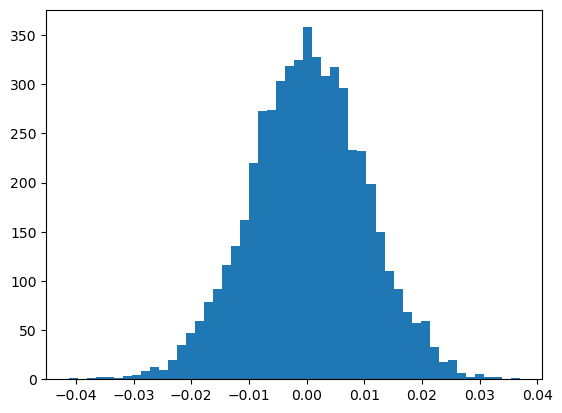

In [12]:
plt.hist(h.view(-1).tolist(), bins=50);

In [21]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn(fan_in, fan_out) / (fan_in ** 0.5)  # He initialization
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight, self.bias] if self.bias is not None else [self.weight]

In [22]:
l1 = Linear(27, 200)
output = l1(torch.randn(10, 27))  # 10 samples, each with 27 features
output.shape  # Should be (10, 200)

torch.Size([10, 200])

In [29]:
l1.parameters()

[tensor([[ 0.0754,  0.1075,  0.3346,  ...,  0.0819,  0.1667, -0.0581],
         [ 0.2679, -0.1241,  0.0348,  ...,  0.0051,  0.1939, -0.1885],
         [-0.4056,  0.5327,  0.1166,  ..., -0.0127, -0.0251, -0.3309],
         ...,
         [-0.1345, -0.1464, -0.0185,  ..., -0.1554,  0.2738,  0.2376],
         [ 0.2707, -0.1148,  0.1814,  ...,  0.0384,  0.2785, -0.2969],
         [ 0.0887, -0.0633,  0.0178,  ...,  0.0290,  0.1217, -0.3343]]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 

In [31]:
# TODO: Implement a simple version of Batch Normalization
class BarchNorm1d:
    def __init__(self):
        pass